In [13]:
print("hi")

hi


In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

/Users/sachinmishra/Desktop/GenAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
import os
load_dotenv(override=True)

python-dotenv could not parse statement starting at line 3


True

In [4]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        max_tokens= 1000
    )

In [5]:
llm= get_groq_llm()

In [6]:
class LLMState(TypedDict):
    question: str
    answer: str

In [7]:
def chat_llm(state: LLMState):

    question= state['question']

    ##prompt:
    prompt= f'Answer the following Question {question}'

    answer= llm.invoke(prompt).content
    
    state['answer']= answer

    return state


    


In [8]:
graph= StateGraph(LLMState)

## add nodes

graph.add_node('chat_llm',chat_llm)

In [9]:
## add edges

graph.add_edge(START,'chat_llm')
graph.add_edge('chat_llm', END)

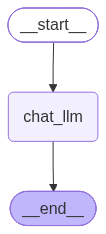

In [10]:
workflow= graph.compile()

workflow

In [11]:
intial_state= {'question':'How far is the moon from earth'}

final_state= workflow.invoke(intial_state)

print(final_state)

{'question': 'How far is the moon from earth', 'answer': 'The Moon’s distance from Earth isn’t a single fixed number because its orbit is slightly elliptical, but the commonly quoted values are:\n\n| Metric | Approximate Value |\n|--------|-------------------|\n| **Average (mean) distance** | **384,400\u202fkm** (≈\u202f238,855\u202fmi) |\n| **Perigee (closest point)** | ~363,300\u202fkm (≈\u202f225,600\u202fmi) |\n| **Apogee (farthest point)** | ~405,500\u202fkm (≈\u202f251,900\u202fmi) |\n| **Light‑travel time** | ~1.28\u202fseconds one‑way |\n\nSo, on average, the Moon lies about **384\u202f000 kilometres (239\u202f000 miles)** away from Earth. The actual distance at any given moment will be somewhere between roughly **363\u202f000\u202fkm** and **406\u202f000\u202fkm**, depending on where the Moon is in its elliptical orbit.'}


In [12]:
print(final_state['answer'])

The Moon’s distance from Earth isn’t a single fixed number because its orbit is slightly elliptical, but the commonly quoted values are:

| Metric | Approximate Value |
|--------|-------------------|
| **Average (mean) distance** | **384,400 km** (≈ 238,855 mi) |
| **Perigee (closest point)** | ~363,300 km (≈ 225,600 mi) |
| **Apogee (farthest point)** | ~405,500 km (≈ 251,900 mi) |
| **Light‑travel time** | ~1.28 seconds one‑way |

So, on average, the Moon lies about **384 000 kilometres (239 000 miles)** away from Earth. The actual distance at any given moment will be somewhere between roughly **363 000 km** and **406 000 km**, depending on where the Moon is in its elliptical orbit.


In [26]:
intial_state= {'question':'okay great but how far from Sun?'}

final_state= workflow.invoke(intial_state)

In [27]:
print(final_state)

{'question': 'okay great but how far from Sun?', 'answer': 'The average distance from the Sun to the Earth is about **149.6\u202fmillion kilometres (km)**, which is defined as **1 astronomical unit (AU)**.  \n\n### A quick rundown of the Earth–Sun distance\n\n| Parameter | Value | Explanation |\n|-----------|-------|-------------|\n| **Mean (average) distance** | ≈\u202f149.6\u202fmillion\u202fkm (≈\u202f93\u202fmillion\u202fmi) | This is the value we usually quote as “the distance to the Sun.” |\n| **Astronomical Unit (AU)** | 1\u202fAU = 149\u202f597\u202f870.7\u202fkm | A convenient unit for solar‑system scales. |\n| **Perihelion (closest point)** | ≈\u202f147.1\u202fmillion\u202fkm (≈\u202f91.4\u202fmillion\u202fmi) | Occurs around\u202fearly\u202fJanuary. |\n| **Aphelion (farthest point)** | ≈\u202f152.1\u202fmillion\u202fkm (≈\u202f94.5\u202fmillion\u202fmi) | Occurs around\u202fearly\u202fJuly. |\n| **Variation over a year** | ±\u202f≈\u202f1.5\u202fmillion\u202fkm (≈\u202f0.01\

In [28]:
print(final_state['answer'])


The average distance from the Sun to the Earth is about **149.6 million kilometres (km)**, which is defined as **1 astronomical unit (AU)**.  

### A quick rundown of the Earth–Sun distance

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| **Mean (average) distance** | ≈ 149.6 million km (≈ 93 million mi) | This is the value we usually quote as “the distance to the Sun.” |
| **Astronomical Unit (AU)** | 1 AU = 149 597 870.7 km | A convenient unit for solar‑system scales. |
| **Perihelion (closest point)** | ≈ 147.1 million km (≈ 91.4 million mi) | Occurs around early January. |
| **Aphelion (farthest point)** | ≈ 152.1 million km (≈ 94.5 million mi) | Occurs around early July. |
| **Variation over a year** | ± ≈ 1.5 million km (≈ 0.01 AU) | Roughly a 3 % swing due to the Earth’s slightly elliptical orbit. |

### Why the distance matters

* **Solar energy:** The amount of solar energy reaching Earth (the solar constant) is about **1361 W m⁻²** at 1 AU. A small c

## Call to llm:
## Stateless Calls: It does not have any previous message history



##

User_query_no1: hsxbshbxh
llm: hsxbhjsxhbv

user_q2: follow up question
llm: proper answe

## sending all prev, info to llm